# Reading and visualising a mesh with meshio++ (C++ / xeus-cpp)

This is the C++ counterpart of
[`01_read_and_visualize.ipynb`](../example/01_read_and_visualize.ipynb): the
same bracket geometry, meshio++'s **C++ core** directly, no Python involved.
It runs on the [xeus-cpp](https://github.com/compiler-research/xeus-cpp)
Jupyter kernel against `meshioplusplus.hpp`, the committed
[single-header amalgamation](../doc/single_header.md) — `#include` it,
`#define MESHIOPLUSPLUS_IMPLEMENTATION` once, and the whole core (every
format, every operation) is available with no separate build step.

There is no PyVista in C++, so instead of rendering through VTK, these
notebooks lean on meshio++'s own **SVG writer**: it already does the camera
projection and data-driven colouring PyVista would
(`doc/formats/svg.md#data-driven-colouring`), needs no extra dependency, and
keeps the "meshio++'s core has no rendering dependency" rule intact. A small
helper header, [`mio_notebook.hpp`](./mio_notebook.hpp), wraps `write_svg`
and hands the result to Jupyter's rich-display mechanism
(`xcpp::display`) as an `image/svg+xml` output.

The input is [`example.vtu`](./example.vtu), not `example/example.msh`
directly: Gmsh 4.1's `$Entities` section (present in the original file) is a
documented gap in meshio++'s **C++** reader — the Python bindings paper over
it with a pure-Python fallback that a C++-only kernel does not have.
`example.vtu` is the identical bracket geometry (points, triangle skin,
tetra volume), pre-converted once with the Python bindings; see this
folder's [`README.md`](./README.md) for how and why.

In [ ]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
#include <iomanip>
#include <cmath>
#include <algorithm>
#include <numeric>
#include <random>
#include <chrono>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

using namespace meshioplusplus;
using namespace mio_nb;

## Read the mesh

In [2]:
Mesh mesh = registry_read("example.vtu", resolve_format("example.vtu", ""), {});

std::cout << "points      : " << mesh.NumPoints() << "\n";
std::cout << "cell blocks : " << mesh.NumCellBlocks() << "\n";
std::cout << "cell totals :\n";
for (std::size_t i = 0; i < mesh.NumCellBlocks(); ++i) {
    auto cv = mesh.Cells(i);
    std::cout << "    " << std::left << std::setw(10) << cv.Type() << std::right << std::setw(8)
              << cv.NumCells() << "\n";
}

auto stats = compute_stats(mesh);
std::cout << "bounding box: (" << stats.mBBoxMin[0] << ", " << stats.mBBoxMin[1] << ", " << stats.mBBoxMin[2]
          << ") -> (" << stats.mBBoxMax[0] << ", " << stats.mBBoxMax[1] << ", " << stats.mBBoxMax[2] << ")\n";

points      : 52282
cell blocks : 2
cell totals :
    triangle     58394
    tetra       235014
bounding box: (-3.505, -3.185, 0) -> (0, 0.625, 0.382)


## Visualise the full part

`render()` (in `mio_notebook.hpp`) writes the mesh through `write_svg` at an
isometric camera angle and displays the result inline.

In [3]:
xcpp::display(render(mesh));

## Clip to reveal the interior

PyVista's `clip()` cuts a 3D *view* interactively; meshio++'s equivalent is
the operation `crop_halfspace`, which actually removes the cells on one side
of a plane (kept: `(p - point) . normal >= 0`) and returns a real,
smaller mesh — the same building block the CLI's `crop` verb and the
`--plane` flag use. Cropping to the half of the part with `x` below its
midpoint exposes the tetrahedra that were previously hidden inside the
solid.

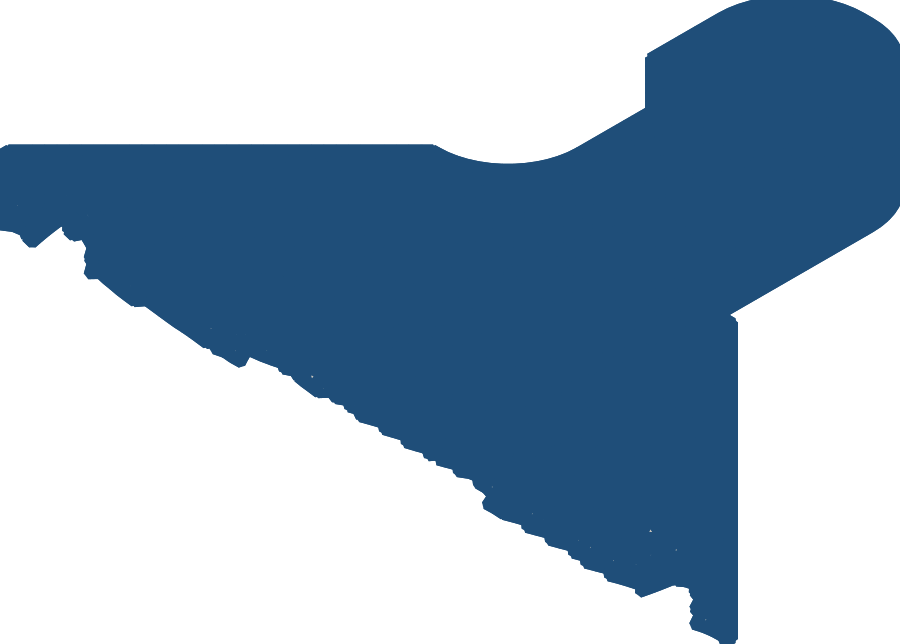

clipped points: 17741 (from 52282)


In [4]:
double lo[3], hi[3];
{
    auto s = compute_stats(mesh);
    for (int d = 0; d < 3; ++d) { lo[d] = s.mBBoxMin[d]; hi[d] = s.mBBoxMax[d]; }
}
double mid_x = 0.5 * (lo[0] + hi[0]);
double plane_point[3] = {mid_x, 0.0, 0.0};
double plane_normal[3] = {-1.0, 0.0, 0.0};   // keep x <= mid_x

CropResult clipped = crop_halfspace(mesh, plane_point, plane_normal, CropMode::Any, false);
std::cout << "clipped points: " << clipped.mMesh.NumPoints() << " (from " << mesh.NumPoints() << ")\n";
xcpp::display(render(clipped.mMesh));

## Vector figures coloured by a field

The renders above are already vector figures (SVG), not rasters — that is
the point of writing through `write_svg` rather than rastering a GL view. We
colour by element quality: `attach_quality` writes each metric back as
`cell_data`, and because the SVG writer projects the mesh's *skin*, it
tracks each boundary facet back to the volume cell that owns it, so the
colour on a facet really is that element's `scaled_jacobian`.

The bracket is cropped to a legible corner first — the full skin is tens of
thousands of facets, too fine for a static figure.

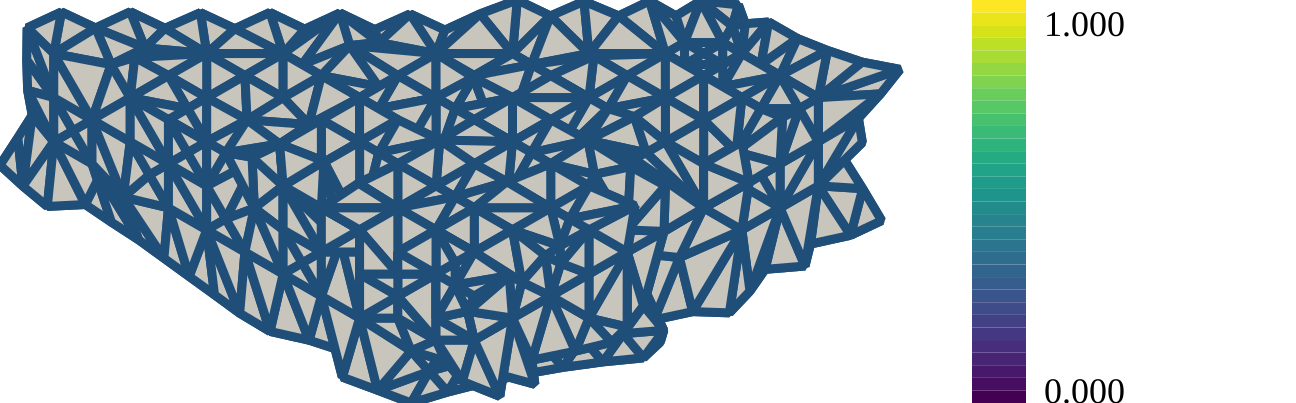

corner: 772 points, 2842 tetrahedra


In [5]:
double corner_hi[3];
for (int d = 0; d < 3; ++d) corner_hi[d] = lo[d] + (hi[d] - lo[d]) * 0.4;
CropResult corner = crop_bbox(mesh, lo, corner_hi, CropMode::All, false);

Mesh annotated = attach_quality(corner.mMesh);
std::cout << "corner: " << annotated.NumPoints() << " points, "
          << annotated.Cells(annotated.NumCellBlocks() - 1).NumCells() << " tetrahedra\n";

xcpp::display(render(annotated, "quality:scaled_jacobian", "viridis", true, 0.0, 1.0));

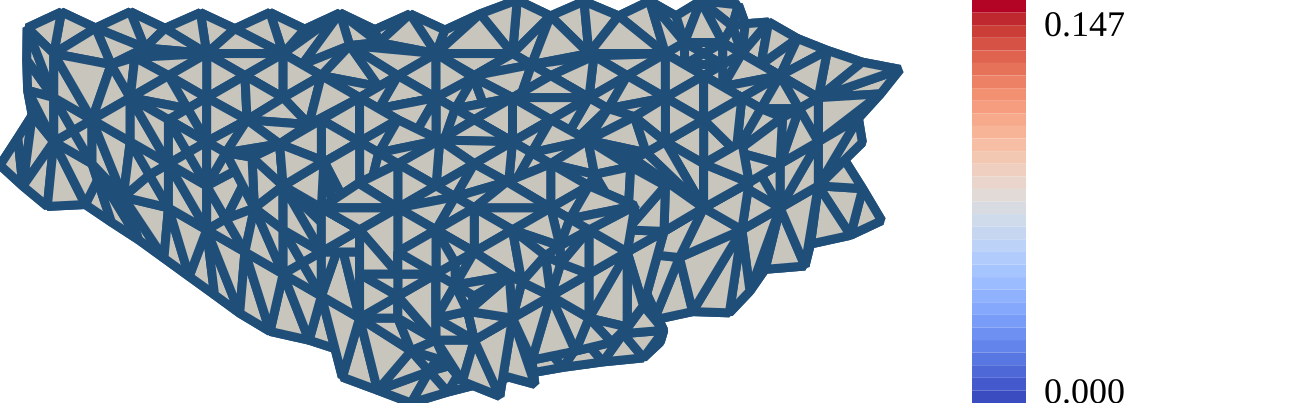

In [6]:
// Point data works too, averaged over each face's corners -- a diverging
// colormap suits a signed quantity (height relative to the corner's own
// centroid) better than a sequential one.
Mesh withHeight = corner.mMesh;
const NDArray& pts = withHeight.Points();
NDArray height(DType::Float64, {withHeight.NumPoints()});
double* hd = height.As<double>();
const double* pd = pts.As<double>();
for (std::size_t i = 0; i < withHeight.NumPoints(); ++i) hd[i] = pd[i * 3 + 2];
withHeight.AddPointData("z", std::move(height));

xcpp::display(render(withHeight, "z", "coolwarm", true));

The same options are available on the command line —
`meshioplusplus convert mesh.vtu figure.svg --color-by NAME --colorbar` —
and from the TikZ writer (`write_tikz`), which emits the identical figure as
LaTeX.

That's the round trip: **meshio++'s C++ core reads the mesh**, computes
quality metrics on it, and its own SVG writer renders it — no Python, no
external rendering library. See
[`02_convert_and_inspect.ipynb`](./02_convert_and_inspect.ipynb) for
converting the same mesh between formats, and
[`03_mesh_operations.ipynb`](./03_mesh_operations.ipynb) for the rest of the
operations layer.